# Lapse-rate statistical downscaling — TMP2m over Japan

MVP notebook for a simple, fast DEM-based (lapse-rate) statistical downscaling
of ACE2S 2 m temperature output. Goal: go from the ~1° global ACE2S grid to a
high-resolution grid by correcting for the elevation difference between the
coarse and fine DEM, using a fixed (or later, calibrated) environmental lapse
rate. The target high-res grid is matched to **HiRO's own precipitation output
resolution** (~3 km / 0.03125°), so the corrected temperature field lines up
pixel-for-pixel with HiRO's downscaled precip.

Sections:
1. Load the right low-res temperature field(s)
2. Match HiRO's target grid, focus on Japan
3. Low-res DEM (from the HiRO-ACE forcing data)
4. High-res DEM — sourcing, resolution-matching strategy, and a real
   ETOPO-2022-based DEM block-averaged onto HiRO's exact grid
5. Lapse-rate correction function (in-memory + zarr-efficient)
6. Apply & compare low-res vs. DEM-corrected fields
7. Distribution / extremes metrics
8. What's next


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import xarray as xr
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator

plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.facecolor"] = "white"


In [2]:
# This notebook lives in temperature_downscaling/scripts/
TDS_ROOT = Path("..").resolve()      # .../local/temperature_downscaling
LOCAL_ROOT = TDS_ROOT.parent          # .../local

ACE2S_ZARR = TDS_ROOT / "ace2s" / "output_6hourly_ace2s_ic0000.zarr"
FORCING_NC = LOCAL_ROOT / "HiRO-ACE" / "forcing_data" / "forcing_2023.nc"
HIRO_ZARR = LOCAL_ROOT / "output" / "hiro_downscaled" / "Japan_two_steps_20230101_0000_0600.zarr"

DEM_CACHE_DIR = TDS_ROOT / "dem_cache"
DEM_CACHE_DIR.mkdir(exist_ok=True)

assert ACE2S_ZARR.exists(), f"missing {ACE2S_ZARR}"
assert FORCING_NC.exists(), f"missing {FORCING_NC}"
assert HIRO_ZARR.exists(), f"missing {HIRO_ZARR}"
ACE2S_ZARR, FORCING_NC, HIRO_ZARR


(PosixPath('/Users/valentin/Desktop/UNRISK/Projects/Climate_models/HiroACE/local/temperature_downscaling/ace2s/output_6hourly_ace2s_ic0000.zarr'),
 PosixPath('/Users/valentin/Desktop/UNRISK/Projects/Climate_models/HiroACE/local/HiRO-ACE/forcing_data/forcing_2023.nc'),
 PosixPath('/Users/valentin/Desktop/UNRISK/Projects/Climate_models/HiroACE/local/output/hiro_downscaled/Japan_two_steps_20230101_0000_0600.zarr'))

## 1. Which temperature field?

The ACE2S output carries **two** temperature-like variables on the same 1°
grid:

| variable | what it physically is | good for lapse-rate DEM correction? |
|---|---|---|
| `TMP2m` | 2 m **air** temperature (screen-level) | **Yes — this is the one to use.** Lapse rate describes how *air* temperature falls off with height in the atmosphere; this is exactly the standard variable used in downscaling products like WorldClim/PRISM/CHELSA. |
| `surface_temperature` | **skin/land surface** temperature (radiative skin temp of the land/ocean surface) | Not directly — it's driven by the surface energy balance (solar heating, albedo, evapotranspiration, snow cover), not just adiabatic cooling with height. Using it here would conflate elevation effects with surface-type effects. |

So: **`TMP2m` is the field we downscale.** `surface_temperature` is still
useful — just not for this method. It (and `land_fraction`, `UGRD10m` /
`VGRD10m`, `PRATEsfc`) becomes interesting as a **conditioning input** if you
later move to a regression/ML-based downscaler instead of a fixed lapse rate:
e.g. slope/aspect × wind direction for orographic effects, `land_fraction`
to blend coastal grid cells correctly, incoming shortwave for the diurnal
cycle.

**Precipitation (`PRATEsfc`) is a separate problem** — it does *not* scale
lapse-rate-style with elevation. Orographic precipitation enhancement is
non-linear, depends on wind direction relative to terrain slope/aspect, and
involves convective/microphysical processes. It needs a different method
(quantile mapping, or an orographic-enhancement/ML model conditioned on
terrain roughness + wind), which is a good phase-2 extension of this repo but
out of scope for this lapse-rate MVP. Flagging it since you asked — happy to
scope that separately if useful.


In [3]:
ds = xr.open_zarr(ACE2S_ZARR)
ds


<xarray.Dataset> Size: 2GB
Dimensions:              (time: 1459, lat: 180, lon: 360, z_interface: 9)
Coordinates:
  * time                 (time) object 12kB 2023-01-01 06:00:00 ... 2023-12-3...
  * lat                  (lat) float32 720B -89.24 -88.25 -87.25 ... 88.25 89.24
  * lon                  (lon) float32 1kB 0.5 1.5 2.5 3.5 ... 357.5 358.5 359.5
    ak                   (z_interface) float32 36B ...
    bk                   (z_interface) float32 36B ...
Dimensions without coordinates: z_interface
Data variables:
    PRATEsfc             (time, lat, lon) float32 378MB ...
    surface_temperature  (time, lat, lon) float32 378MB ...
    TMP2m                (time, lat, lon) float32 378MB ...
    UGRD10m              (time, lat, lon) float32 378MB ...
    VGRD10m              (time, lat, lon) float32 378MB ...
Attributes:
    source.git_sha:   None
    source.job_id:    None
    history.created:  2026-07-29T12:39:50.668746
    title:            ACE output 6hourly ace2s data

## 2. Match HiRO's target grid, focus on Japan

HiRO's own downscaled precipitation output
(`output/hiro_downscaled/Japan_two_steps_20230101_0000_0600.zarr`) is on a
**~3 km grid (0.0312° x 0.0312°, 704 x 736 points)** covering Japan — much
finer than the 1° ACE2S grid, and *that* is the real resolution we want our
DEM (and eventually the DEM-corrected temperature) matched to, so it lines up
pixel-for-pixel with HiRO's precip output. We pull that grid's exact lat/lon
coordinates now and use them everywhere below as the "high-res target".


In [4]:
hiro_ds = xr.open_zarr(HIRO_ZARR)
TARGET_LAT = hiro_ds["latitude"].values.astype("float64")
TARGET_LON = hiro_ds["longitude"].values.astype("float64")

print(f"HiRO target grid: {len(TARGET_LAT)} x {len(TARGET_LON)} points, "
      f"spacing ~{np.median(np.diff(TARGET_LAT)):.4f}° x {np.median(np.diff(TARGET_LON)):.4f}° "
      f"(~{np.median(np.diff(TARGET_LAT)) * 111:.1f} km)")
print(f"lat: {TARGET_LAT.min():.2f} to {TARGET_LAT.max():.2f}, lon: {TARGET_LON.min():.2f} to {TARGET_LON.max():.2f}")

# Pad by 1 deg so the low-res fields we regrid FROM fully cover the target extent
JAPAN_BBOX = dict(
    lat_min=float(TARGET_LAT.min()) - 1.0, lat_max=float(TARGET_LAT.max()) + 1.0,
    lon_min=float(TARGET_LON.min()) - 1.0, lon_max=float(TARGET_LON.max()) + 1.0,
)
JAPAN_BBOX


HiRO target grid: 704 x 736 points, spacing ~0.0312° x 0.0312° (~3.5 km)
lat: 23.95 to 45.86, lon: 123.02 to 145.98


{'lat_min': 22.94900131225586,
 'lat_max': 46.85676956176758,
 'lon_min': 122.015625,
 'lon_max': 146.984375}

In [5]:
def subset_region(da, bbox=JAPAN_BBOX, lat_name="lat", lon_name="lon"):
    return da.sel(**{
        lat_name: slice(bbox["lat_min"], bbox["lat_max"]),
        lon_name: slice(bbox["lon_min"], bbox["lon_max"]),
    })


def to_celsius(da):
    out = da - 273.15
    out.attrs.update(da.attrs)
    out.attrs["units"] = "degC"
    return out


t2m_japan = subset_region(ds["TMP2m"])
t2m_japan


<xarray.DataArray 'TMP2m' (time: 1459, lat: 24, lon: 25)> Size: 4MB
[875400 values with dtype=float32]
Coordinates:
  * time     (time) object 12kB 2023-01-01 06:00:00 ... 2023-12-31 18:00:00
  * lat      (lat) float32 96B 23.43 24.43 25.43 26.43 ... 44.38 45.37 46.37
  * lon      (lon) float32 100B 122.5 123.5 124.5 125.5 ... 144.5 145.5 146.5
Attributes:
    units:      K
    long_name:  2m temperature [K]

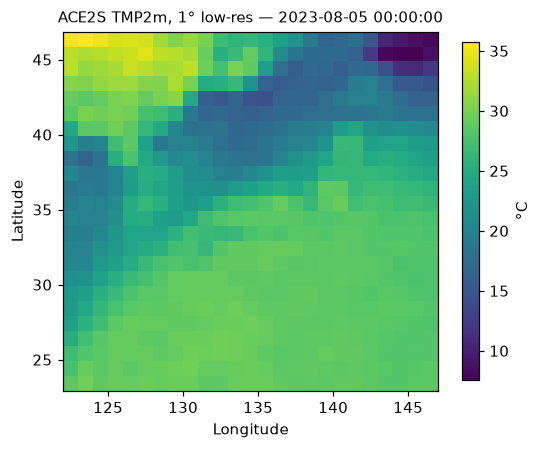

In [6]:
def plot_field(da, title, cmap="viridis", cbar_label="", ax=None, vmin=None, vmax=None):
    da = da.squeeze()
    if ax is None:
        _, ax = plt.subplots(figsize=(5.5, 5))
    pcm = ax.pcolormesh(da[da.dims[-1]], da[da.dims[-2]], da.values,
                         cmap=cmap, vmin=vmin, vmax=vmax, shading="auto")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    ax.set_aspect("equal")
    plt.colorbar(pcm, ax=ax, label=cbar_label, shrink=0.8)
    return ax


PLOT_TIME = "2023-08-05T00:00:00"  # a summer timestep -> clear land/sea + elevation signal

t2m_c_japan = to_celsius(t2m_japan).sel(time=PLOT_TIME).squeeze("time")

plot_field(t2m_c_japan,
           f"ACE2S TMP2m, 1° low-res — {str(t2m_c_japan.time.values)}",
           cmap="viridis", cbar_label="°C")
plt.show()


Notice how blocky this is — Hokkaido, the Kanto plain, and the central
Japanese Alps are all smeared across the same handful of 1° cells.

## 3. Low-res DEM

The ACE2S/SHiELD-AMIP forcing data ships the model's own surface height field,
`HGTsfc`, in `HiRO-ACE/forcing_data/forcing_2023.nc` — on the **exact same**
180×360 lat/lon grid as the zarr output (verified: identical coordinate
arrays), so no regridding is needed to pair it with `TMP2m`.


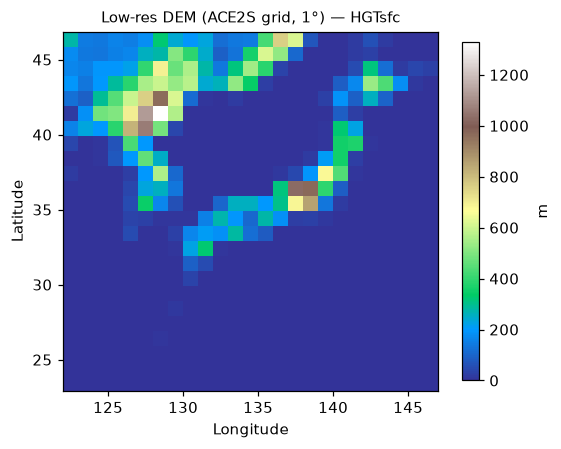

In [7]:
forcing = xr.open_dataset(FORCING_NC)
hgt_low = forcing["HGTsfc"].rename({"latitude": "lat", "longitude": "lon"})
hgt_low_japan = subset_region(hgt_low)

plot_field(hgt_low_japan, "Low-res DEM (ACE2S grid, 1°) — HGTsfc", cmap="terrain", cbar_label="m")
plt.show()


## 4. High-res DEM

`HGTsfc` above **is** the model's own (coarse) orography — nothing in this
repo ships a true high-res DEM. Candidate real sources, roughly best-fit-for-
Japan first:

| source | resolution | format | notes |
|---|---|---|---|
| **JAXA ALOS World 3D (AW3D30)** | 30 m | GeoTIFF | Japan's own space agency product, arguably the best-validated one specifically over Japan. Free registration required — no scriptable no-auth download. |
| **Copernicus DEM (GLO-30)** | 30 m | Cloud-Optimized GeoTIFF | Public AWS bucket, no login, but tiled 1°x1° — the full domain here is ~500 tiles / several GB, and needs `rioxarray`/`rasterio`. |
| **NASA SRTM (SRTMGL1), via OpenTopography** | 30 m | GeoTIFF | Classic choice, same GeoTIFF/GDAL dependency as above. |
| **NOAA ETOPO 2022** | 15 arc-sec (~460 m) | NetCDF, subsettable via public ERDDAP | **Used below.** Loads with plain `xarray`/`requests` — no GDAL. |

### Resolution-matching strategy

The actual target here is HiRO's **~3 km** grid (§2), not "as fine as
possible." That changes the right approach in two ways:

- **ETOPO's 460 m is already ~6-7x finer than the 3 km target per axis
  (~45x more points per target cell)** — plenty to average down cleanly,
  without paying for the ~100x-finer 30 m products (which would mean
  downloading/processing several GB across this whole domain for no benefit,
  since the *target* resolution is what limits how much detail actually
  survives).
- **Aggregate with an area/block mean onto HiRO's exact grid — not
  nearest-neighbor point sampling.** HiRO's 3 km cells represent
  cell-area-averaged values, so the elevation paired with each cell should be
  a cell-area-average too. Picking the single closest fine-DEM pixel per cell
  would just grab one arbitrary point (could be a valley floor or a ridge
  top) instead of the representative mean, and that mismatch shows up
  directly as noise in the lapse-rate correction.


In [8]:
ETOPO_ERDDAP_URL = "https://oceanwatch.pifsc.noaa.gov/erddap/griddap/ETOPO_2022_v1_15s.nc"
ETOPO_CACHE = DEM_CACHE_DIR / "etopo2022_15s_japan.nc"


def fetch_etopo_2022(lat_min, lat_max, lon_min, lon_max, cache_path=ETOPO_CACHE, pad=0.05):
    """Fetch (and cache) an ETOPO 2022, 15 arc-second (~460 m) relief subset
    from NOAA's public ERDDAP server (no auth needed) covering a lat/lon bbox.
    """
    if cache_path.exists():
        return xr.open_dataset(cache_path)["z"]

    query = (f"z%5B({lat_min - pad}):({lat_max + pad})%5D"
             f"%5B({lon_min - pad}):({lon_max + pad})%5D")
    url = f"{ETOPO_ERDDAP_URL}?{query}"
    resp = requests.get(url, timeout=300)
    resp.raise_for_status()
    cache_path.write_bytes(resp.content)
    return xr.open_dataset(cache_path)["z"]


etopo_fine = fetch_etopo_2022(TARGET_LAT.min(), TARGET_LAT.max(), TARGET_LON.min(), TARGET_LON.max())
print(f"ETOPO subset: {etopo_fine.sizes['latitude']} x {etopo_fine.sizes['longitude']} points "
      f"(15 arcsec spacing, ~460 m)")
etopo_fine


ETOPO subset: 5282 x 5569 points (15 arcsec spacing, ~460 m)


<xarray.DataArray 'z' (latitude: 5282, longitude: 5569)> Size: 118MB
[29415458 values with dtype=float32]
Coordinates:
  * latitude   (latitude) float64 42kB 23.9 23.9 23.91 23.91 ... 45.89 45.9 45.9
  * longitude  (longitude) float64 45kB 122.9 122.9 122.9 ... 146.1 146.1 146.1
Attributes:
    ioos_category:  Location
    long_name:      Z

In [9]:
def cell_edges(centers):
    """Midpoint cell edges for a (roughly) regular 1-D coordinate array."""
    centers = np.asarray(centers, dtype="float64")
    mid = (centers[:-1] + centers[1:]) / 2
    edges = np.empty(len(centers) + 1)
    edges[1:-1] = mid
    edges[0] = centers[0] - (mid[0] - centers[0])
    edges[-1] = centers[-1] + (centers[-1] - mid[-1])
    return edges


def block_mean_regrid(da, target_lat, target_lon, lat_name="latitude", lon_name="longitude",
                       return_std=False, min_value=None):
    """Conservative area-average of a fine-resolution (lat, lon) DataArray onto
    a coarser target grid: every output cell = mean of all source pixels whose
    center falls inside that cell (bounded by midpoints to its neighbors).
    This is the right operation when the target grid represents cell-area
    averages (as HiRO's downscaled output does) -- not nearest-neighbor point
    sampling, which would just pick one arbitrary source pixel per cell.

    min_value : if given, source pixels with da <= min_value are excluded
        entirely from the average (not counted toward it) -- e.g. min_value=0
        to compute a land-only mean elevation by dropping ocean/bathymetry
        pixels. Target cells left with zero qualifying pixels come back NaN,
        same as target cells with no source coverage at all.
    """
    lat_edges = cell_edges(target_lat)
    lon_edges = cell_edges(target_lon)

    lat_idx = np.searchsorted(lat_edges, da[lat_name].values, side="right") - 1
    lon_idx = np.searchsorted(lon_edges, da[lon_name].values, side="right") - 1
    valid_lat = (lat_idx >= 0) & (lat_idx < len(target_lat))
    valid_lon = (lon_idx >= 0) & (lon_idx < len(target_lon))
    n_lat_t, n_lon_t = len(target_lat), len(target_lon)
    lat_idx_c = np.clip(lat_idx, 0, n_lat_t - 1)
    lon_idx_c = np.clip(lon_idx, 0, n_lon_t - 1)
    flat_idx = lat_idx_c[:, None] * n_lon_t + lon_idx_c[None, :]
    mask = valid_lat[:, None] & valid_lon[None, :]
    if min_value is not None:
        mask = mask & (da.values > min_value)

    values = da.values
    flat_idx_m = flat_idx[mask]
    values_m = values[mask]

    sums = np.bincount(flat_idx_m, weights=values_m, minlength=n_lat_t * n_lon_t)
    sq_sums = np.bincount(flat_idx_m, weights=values_m ** 2, minlength=n_lat_t * n_lon_t)
    counts = np.bincount(flat_idx_m, minlength=n_lat_t * n_lon_t)

    counts_safe = np.maximum(counts, 1)
    mean = (sums / counts_safe).reshape(n_lat_t, n_lon_t)
    mean[counts.reshape(n_lat_t, n_lon_t) == 0] = np.nan

    mean_da = xr.DataArray(mean, dims=("lat", "lon"),
                            coords={"lat": target_lat, "lon": target_lon},
                            name=getattr(da, "name", "value"))
    if not return_std:
        return mean_da

    var = (sq_sums / counts_safe).reshape(n_lat_t, n_lon_t) - mean ** 2
    std = np.sqrt(np.clip(var, 0, None))
    std_da = xr.DataArray(std, dims=("lat", "lon"),
                           coords={"lat": target_lat, "lon": target_lon},
                           name=f"{mean_da.name}_std")
    return mean_da, std_da


# ETOPO is a combined land/ocean relief model (ocean cells hold negative
# bathymetric depth, sometimes thousands of meters), while the ACE2S model's
# own HGTsfc treats the ocean surface as ~0 m. A coastal target cell mixes
# both kinds of fine pixels, so averaging them together (then clipping the
# result to 0) dilutes/understates the cell's actual land elevation with
# irrelevant seafloor depth.
#
# Fix, scoped to only change cells that actually contain land:
#  - land-only mean (min_value=0): drops ocean pixels entirely, so a coastal
#    cell's elevation reflects just its land portion. Cells with ZERO land
#    pixels (open ocean) come back NaN here.
#  - all-pixel mean, clipped to >=0: today's original approach, kept only as
#    the fallback for those NaN (100%-ocean) cells, where it already comes
#    out ~0 -- matching the low-res model's own sea-level convention, so the
#    lapse-rate correction stays ~0 over open water instead of becoming NaN.
# Note this does NOT fix `T_low`'s own bilinear interpolation blending
# land/ocean 1° values across the coastline -- that's a separate, still-open
# issue, see §8.
hgt_high_land, hgt_high_std = block_mean_regrid(etopo_fine, TARGET_LAT, TARGET_LON,
                                                 return_std=True, min_value=0)
hgt_high_all_clipped = block_mean_regrid(etopo_fine, TARGET_LAT, TARGET_LON).clip(min=0)

hgt_high = xr.where(np.isnan(hgt_high_land), hgt_high_all_clipped, hgt_high_land)
hgt_high.attrs.update(
    units="m",
    long_name=("High-res DEM: ETOPO 2022 15-arcsec, land-only block mean onto HiRO's 3 km grid "
               "(open-ocean cells fall back to 0 m)"),
)
hgt_high


<xarray.DataArray 'z' (lat: 704, lon: 736)> Size: 4MB
array([[  0.        ,   0.        ,   0.        , ...,   0.        ,
          0.        ,   0.        ],
       [  0.        ,   0.        ,   0.        , ...,   0.        ,
          0.        ,   0.        ],
       [  0.        ,   0.        ,   0.        , ...,   0.        ,
          0.        ,   0.        ],
       ...,
       [140.86579521, 143.00821577, 142.58340734, ...,   0.        ,
          0.        ,   0.        ],
       [140.1261801 , 141.63064814, 141.93988746, ...,   0.        ,
          0.        ,   0.        ],
       [139.64175228, 140.19377981, 140.51278033, ...,   0.        ,
          0.        ,   0.        ]], shape=(704, 736))
Coordinates:
  * lat      (lat) float64 6kB 23.95 23.98 24.01 24.04 ... 45.79 45.83 45.86
  * lon      (lon) float64 6kB 123.0 123.0 123.1 123.1 ... 145.9 146.0 146.0
Attributes:
    units:      m
    long_name:  High-res DEM: ETOPO 2022 15-arcsec, land-only block mean onto...

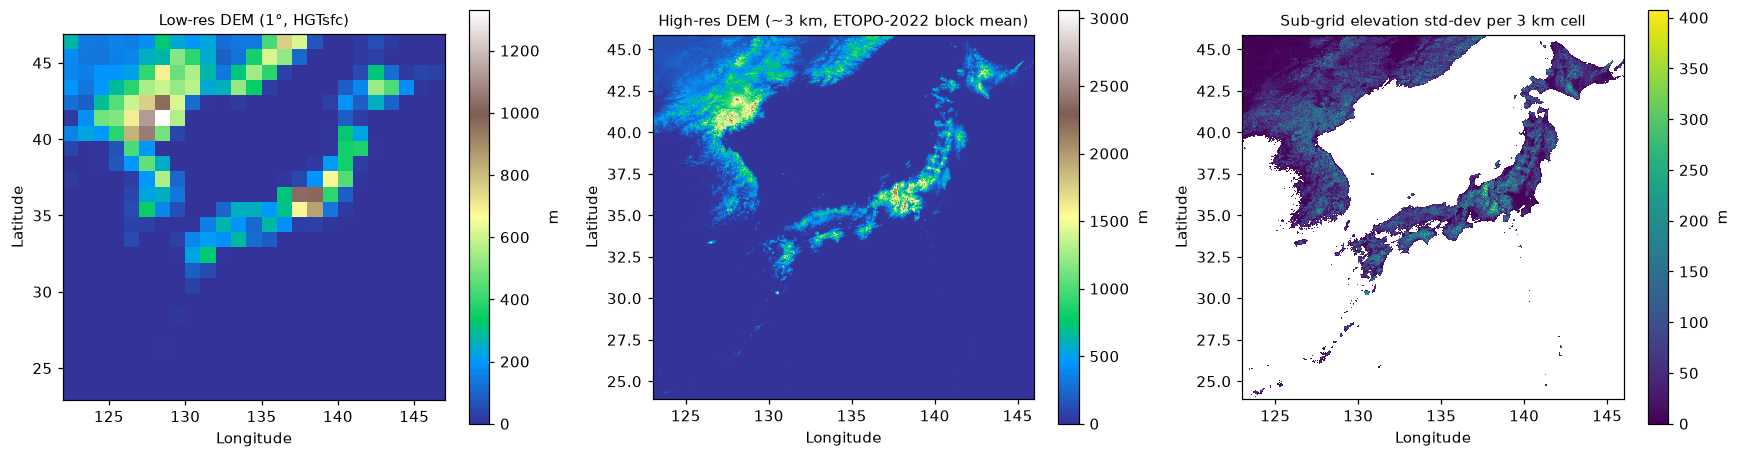

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
plot_field(hgt_low_japan, "Low-res DEM (1°, HGTsfc)", cmap="terrain", cbar_label="m", ax=axes[0])
plot_field(hgt_high, "High-res DEM (~3 km, ETOPO-2022 block mean)", cmap="terrain", cbar_label="m", ax=axes[1])
plot_field(hgt_high_std, "Sub-grid elevation std-dev per 3 km cell", cmap="viridis", cbar_label="m", ax=axes[2])
fig.tight_layout()
plt.show()


The block-averaged DEM shows real terrain structure (individual valleys and
ridges) that the 1° field completely misses. The sub-grid std-dev panel is a
bonus terrain-roughness diagnostic — cells with a high std-dev are ones where
"mean elevation" is a shakier single-number summary (steep terrain, or a cell
straddling a coastline/ridge); useful later for orographic precip work or for
flagging where the lapse-rate assumption is weakest.

## 5. Lapse-rate correction

$$T_{high}(x) = T_{low \to high}(x) - \Gamma \cdot \big(z_{high}(x) - z_{low \to high}(x)\big)$$

where both the coarse temperature *and* the coarse DEM are first bilinearly
regridded onto the target high-res grid, and $\Gamma$ is the (positive)
lapse rate in K/m — default 0.0065 K/m (~6.5 K/km, the standard environmental
lapse rate; the dry-adiabatic rate is steeper at ~0.0098 K/m, moist-annual-mean
effective rates are often shallower at 0.004–0.006 K/m — worth calibrating
locally later, see §8).


In [11]:
DEFAULT_LAPSE_RATE = 0.0065  # K/m, positive => temperature falls with height


def regrid_bilinear(da, target_lat, target_lon, lat_name="lat", lon_name="lon"):
    """Bilinear regrid of a 2-D (lat, lon) DataArray onto a new lat/lon grid."""
    interp = RegularGridInterpolator(
        (da[lat_name].values, da[lon_name].values), da.values,
        method="linear", bounds_error=False, fill_value=None,
    )
    lon_g, lat_g = np.meshgrid(target_lon, target_lat)
    values = interp((lat_g, lon_g))
    return xr.DataArray(values, dims=(lat_name, lon_name),
                         coords={lat_name: target_lat, lon_name: target_lon})


def lapse_rate_correct(t_low, z_low, z_high, lapse_rate=DEFAULT_LAPSE_RATE,
                        lat_name="lat", lon_name="lon"):
    """Statistically downscale a low-res temperature field onto a high-res DEM
    grid via a fixed-lapse-rate correction.

    t_low : xr.DataArray, dims (..., lat, lon) — e.g. (time, lat, lon) or (lat, lon)
    z_low : xr.DataArray, dims (lat, lon) — low-res DEM matching t_low's grid
    z_high: xr.DataArray, dims (lat, lon) — target high-res DEM
    """
    lat_hi, lon_hi = z_high[lat_name].values, z_high[lon_name].values
    z_low_interp = regrid_bilinear(z_low, lat_hi, lon_hi, lat_name, lon_name)
    delta_z = z_high.values - z_low_interp.values  # computed once, reused for every timestep

    if "time" in t_low.dims:
        t_interp = xr.concat(
            [regrid_bilinear(t_low.isel(time=i), lat_hi, lon_hi, lat_name, lon_name)
             for i in range(t_low.sizes["time"])],
            dim=t_low["time"],
        )
    else:
        t_interp = regrid_bilinear(t_low, lat_hi, lon_hi, lat_name, lon_name)

    corrected = t_interp - lapse_rate * delta_z
    corrected.name = t_low.name
    corrected.attrs.update(t_low.attrs)
    corrected.attrs["long_name"] = f"{t_low.attrs.get('long_name', t_low.name)} (lapse-rate DEM corrected)"
    return corrected


In [12]:
# Quick sanity check: if the "high-res" DEM is identical to the (regridded)
# low-res DEM, the lapse-rate term must vanish and the correction should
# reduce to plain bilinear interpolation.
_toy_lat = np.array([0.0, 1.0, 2.0])
_toy_lon = np.array([0.0, 1.0, 2.0])
_toy_t = xr.DataArray(np.array([[290., 291., 292.], [289., 290., 291.], [288., 289., 290.]]),
                       dims=("lat", "lon"), coords={"lat": _toy_lat, "lon": _toy_lon}, name="t")
_toy_z = xr.DataArray(np.array([[0., 10., 20.], [5., 15., 25.], [10., 20., 30.]]),
                       dims=("lat", "lon"), coords={"lat": _toy_lat, "lon": _toy_lon}, name="z")
_toy_target_lat = np.array([0.5, 1.5])
_toy_target_lon = np.array([0.5, 1.5])
_toy_z_same = regrid_bilinear(_toy_z, _toy_target_lat, _toy_target_lon)

_corrected = lapse_rate_correct(_toy_t, _toy_z, _toy_z_same)
_interp_only = regrid_bilinear(_toy_t, _toy_target_lat, _toy_target_lon)
assert np.allclose(_corrected.values, _interp_only.values), "correction should vanish when z_high == z_low_interp"
print("sanity check passed: zero elevation delta -> zero correction")


sanity check passed: zero elevation delta -> zero correction


### Efficient version for zarr

The generator below streams the correction `time_chunk` steps at a time
straight off the zarr store (via the plain xarray + zarr backend — no `dask`
needed here since it isn't installed in this environment; `xr.open_zarr` +
`.isel(time=...).load()` already only reads the requested slice off disk).
Each yielded chunk can be concatenated for a short demo, or written
incrementally to an output zarr store for a full run.


In [13]:
def lapse_rate_correct_zarr(zarr_path, var, z_low, z_high, lapse_rate=DEFAULT_LAPSE_RATE,
                            bbox=None, time_slice=None, time_chunk=50,
                            lat_name="lat", lon_name="lon"):
    """Apply the lapse-rate DEM correction directly against a zarr-backed
    ACE2S output store, processing `time_chunk` timesteps at a time so the
    full series is never materialized in memory. Yields one corrected
    xr.DataArray chunk per iteration.
    """
    ds_ = xr.open_zarr(zarr_path)
    da = ds_[var]
    if bbox is not None:
        da = subset_region(da, bbox, lat_name, lon_name)
    if time_slice is not None:
        da = da.sel(time=time_slice)

    lat_hi, lon_hi = z_high[lat_name].values, z_high[lon_name].values
    z_low_interp = regrid_bilinear(z_low, lat_hi, lon_hi, lat_name, lon_name)
    delta_z = z_high.values - z_low_interp.values

    n_time = da.sizes["time"]
    for start in range(0, n_time, time_chunk):
        chunk = da.isel(time=slice(start, start + time_chunk)).load()
        t_interp = xr.concat(
            [regrid_bilinear(chunk.isel(time=i), lat_hi, lon_hi, lat_name, lon_name)
             for i in range(chunk.sizes["time"])],
            dim=chunk["time"],
        )
        corrected = t_interp - lapse_rate * delta_z
        corrected.name = var
        corrected.attrs.update(da.attrs)
        yield corrected


def write_corrected_to_zarr(zarr_path, var, z_low, z_high, out_path,
                            lapse_rate=DEFAULT_LAPSE_RATE, bbox=None,
                            time_slice=None, time_chunk=50):
    """Consume `lapse_rate_correct_zarr` and stream the result to a new zarr
    store, one time-chunk at a time (append-write, never holds it all in RAM).
    """
    out_path = Path(out_path)
    chunks = lapse_rate_correct_zarr(zarr_path, var, z_low, z_high, lapse_rate,
                                     bbox, time_slice, time_chunk)
    for i, chunk in enumerate(chunks):
        ds_out = chunk.to_dataset()
        ds_out.to_zarr(out_path, mode="w" if i == 0 else "a",
                        append_dim=None if i == 0 else "time")
    return out_path


## 6. Apply & compare

Demo period: **1–10 August 2023**, full Japan domain, DEM-corrected onto
HiRO's real ~3 km target grid (§4) — no more placeholder.


In [14]:
demo_chunks = list(lapse_rate_correct_zarr(
    ACE2S_ZARR, "TMP2m", z_low=hgt_low_japan, z_high=hgt_high,
    bbox=JAPAN_BBOX, time_slice=slice("2023-08-01", "2023-08-10"), time_chunk=20,
))
t2m_corrected_demo = xr.concat(demo_chunks, dim="time")
t2m_corrected_demo = to_celsius(t2m_corrected_demo)
t2m_corrected_demo


<xarray.DataArray 'TMP2m' (time: 40, lat: 704, lon: 736)> Size: 166MB
array([[[28.05013487, 28.09566782, 28.14120078, ..., 28.9403452 ,
         28.9498508 , 28.95935639],
        [28.04862516, 28.09505245, 28.14147973, ..., 28.93127387,
         28.94082209, 28.95037031],
        [28.04711555, 28.09443711, 28.14175866, ..., 28.9222031 ,
         28.93179394, 28.94138477],
        ...,
        [33.07483655, 33.05862441, 33.05909926, ...,  8.61355713,
          8.61992078,  8.62628443],
        [33.09870131, 33.08680148, 33.08267064, ...,  8.58828656,
          8.59369488,  8.59910319],
        [33.12090969, 33.11536636, 33.11133771, ...,  8.5630129 ,
          8.56746576,  8.57191862]],

       [[28.248714  , 28.29041409, 28.33211418, ..., 29.22309502,
         29.23207519, 29.24105536],
        [28.22775449, 28.2698624 , 28.3119703 , ..., 29.21148758,
         29.22034929, 29.22921099],
        [28.20679626, 28.24931196, 28.29182766, ..., 29.19988086,
         29.2086241 , 29.21736735],
...
        [24.62761183, 24.63296491, 24.65500498, ...,  8.70340656,
          8.71145588,  8.7195052 ],
        [24.57415795, 24.58432791, 24.60226685, ...,  8.71360734,
          8.72124374,  8.72888014],
        [24.51903823, 24.53606931, 24.55461508, ...,  8.72380937,
          8.7310328 ,  8.73825623]],

       [[28.17035855, 28.21162985, 28.25290114, ..., 27.3152115 ,
         27.30127019, 27.28732888],
        [28.15438535, 28.19685392, 28.23932249, ..., 27.29914896,
         27.2849911 , 27.27083324],
        [28.13841313, 28.1820789 , 28.22574467, ..., 27.28308741,
         27.26871301, 27.25433861],
        ...,
        [20.26340469, 20.25874424, 20.27077079, ...,  9.13994068,
          9.15674852,  9.17355637],
        [20.24727857, 20.24721983, 20.25493009, ...,  9.12696595,
          9.14375264,  9.16053933],
        [20.22949116, 20.23607837, 20.24418025, ...,  9.11398963,
          9.13075517,  9.14752071]]], shape=(40, 704, 736))
Coordinates:
  * time     (time) object 320B 2023-08-01 00:00:00 ... 2023-08-10 18:00:00
  * lat      (lat) float64 6kB 23.95 23.98 24.01 24.04 ... 45.79 45.83 45.86
  * lon      (lon) float64 6kB 123.0 123.0 123.1 123.1 ... 145.9 146.0 146.0
Attributes:
    units:      degC
    long_name:  2m temperature [K]

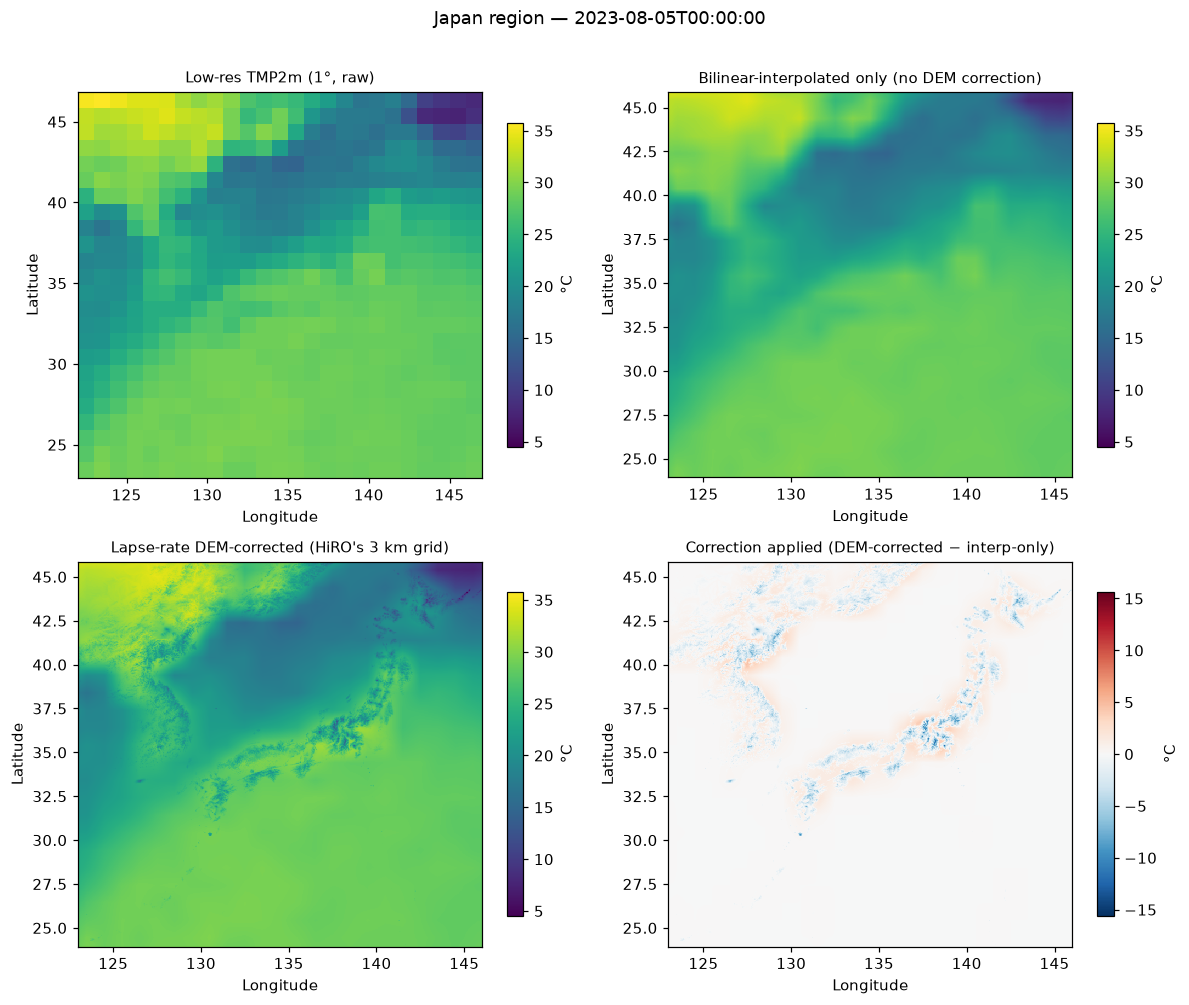

In [15]:
t2m_low_c = to_celsius(t2m_japan).sel(time=PLOT_TIME).squeeze("time")
t2m_interp_only = regrid_bilinear(t2m_low_c, hgt_high.lat.values, hgt_high.lon.values)
t2m_corrected = t2m_corrected_demo.sel(time=PLOT_TIME).squeeze("time")
correction_field = t2m_corrected - t2m_interp_only

vmin = float(min(t2m_low_c.min(), t2m_interp_only.min(), t2m_corrected.min()))
vmax = float(max(t2m_low_c.max(), t2m_interp_only.max(), t2m_corrected.max()))
vmax_c = float(np.nanmax(np.abs(correction_field.values)))

fig, axes = plt.subplots(2, 2, figsize=(11, 9))

plot_field(t2m_low_c, "Low-res TMP2m (1°, raw)", cmap="viridis",
           cbar_label="°C", ax=axes[0, 0], vmin=vmin, vmax=vmax)
plot_field(t2m_interp_only, "Bilinear-interpolated only (no DEM correction)", cmap="viridis",
           cbar_label="°C", ax=axes[0, 1], vmin=vmin, vmax=vmax)
plot_field(t2m_corrected, "Lapse-rate DEM-corrected (HiRO's 3 km grid)", cmap="viridis",
           cbar_label="°C", ax=axes[1, 0], vmin=vmin, vmax=vmax)
plot_field(correction_field, "Correction applied (DEM-corrected − interp-only)", cmap="RdBu_r",
           cbar_label="°C", ax=axes[1, 1], vmin=-vmax_c, vmax=vmax_c)

fig.suptitle(f"Japan region — {PLOT_TIME}", y=1.01)
fig.tight_layout()
plt.show()


Now that the high-res DEM is real terrain (not a smoothed placeholder), the
correction map shows actual ridge/valley structure — individual mountain
ranges cooling relative to their surrounding lowlands, not just a smooth
regional gradient.

## 7. Distribution / extremes metrics

Comparing the DEM-corrected series against the interpolation-only series over
the same demo window (no independent ground truth here — these are internal
comparisons showing what the correction *does*, not an accuracy/skill score;
real validation needs step 1 of §8).


In [16]:
t2m_interp_only_series = xr.concat(
    [regrid_bilinear(to_celsius(t2m_japan).sel(time=t),
                      hgt_high.lat.values, hgt_high.lon.values)
     for t in t2m_corrected_demo.time.values],
    dim=t2m_corrected_demo["time"],
)


def summarize_distribution(da, name):
    values = da.values.ravel()
    values = values[np.isfinite(values)]
    pct = np.percentile(values, [1, 5, 25, 50, 75, 95, 99])
    return pd.Series({
        "mean": values.mean(), "std": values.std(), "min": values.min(),
        "p01": pct[0], "p05": pct[1], "p25": pct[2], "median": pct[3],
        "p75": pct[4], "p95": pct[5], "p99": pct[6], "max": values.max(),
    }, name=name)


metrics = pd.concat([
    summarize_distribution(t2m_corrected_demo, "DEM-corrected"),
    summarize_distribution(t2m_interp_only_series, "Interp-only (no DEM)"),
], axis=1)
metrics["corrected - interp_only"] = metrics["DEM-corrected"] - metrics["Interp-only (no DEM)"]
metrics.round(2)


,DEM-corrected,Interp-only (no DEM),corrected - interp_only
mean,24.74,24.74,0.00
std,4.84,4.79,0.05
min,3.69,6.30,-2.61
p01,12.59,12.92,-0.33
p05,16.14,16.22,-0.08
p25,21.04,21.07,-0.04
median,26.54,26.48,0.05
p75,28.57,28.55,0.02
p95,29.42,29.39,0.03
p99,33.39,33.26,0.13


Share of (grid-cell x timestep) samples below 0°C over Japan, Aug 1-10 2023:
  DEM-corrected :   0.0%
  interp-only   :   0.0%


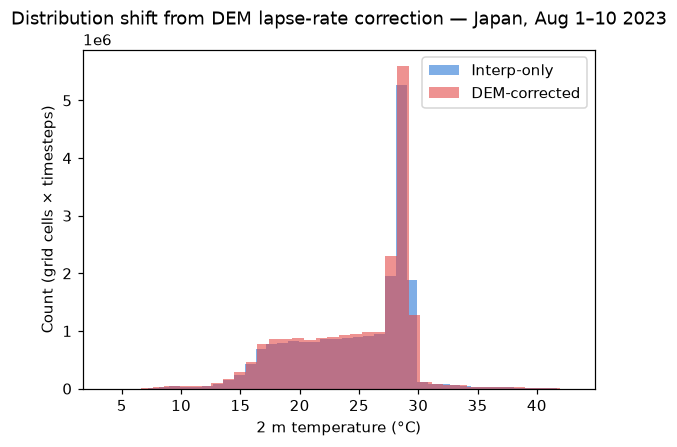

In [17]:
frost_corrected = float((t2m_corrected_demo < 0).mean()) * 100
frost_interp = float((t2m_interp_only_series < 0).mean()) * 100
print(f"Share of (grid-cell x timestep) samples below 0°C over Japan, Aug 1-10 2023:")
print(f"  DEM-corrected : {frost_corrected:5.1f}%")
print(f"  interp-only   : {frost_interp:5.1f}%")

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(t2m_interp_only_series.values.ravel(), bins=40, alpha=0.6, label="Interp-only", color="#2a78d6")
ax.hist(t2m_corrected_demo.values.ravel(), bins=40, alpha=0.6, label="DEM-corrected", color="#e34948")
ax.set_xlabel("2 m temperature (°C)"); ax.set_ylabel("Count (grid cells × timesteps)")
ax.legend()
ax.set_title("Distribution shift from DEM lapse-rate correction — Japan, Aug 1–10 2023")
plt.show()


## 8. What else is worth adding for this MVP

1. **Validate against real observations** — JMA station data, or a gridded
   product (e.g. ERA5-Land, APHRODITE) — to get an actual bias/RMSE/MAE
   skill score. Everything in §7 right now is an internal before/after
   comparison, not accuracy.
2. ~~Proper land–sea mask for the DEM~~ **Done (§4):** the high-res DEM now
   uses a land-only block mean (ocean/bathymetry pixels are excluded from
   each target cell's average, not blended in and clipped afterward), so
   coastal cells no longer have their true land elevation diluted by
   adjacent seafloor depth. Fully-oceanic cells still fall back to 0 m,
   matching the low-res model's own sea-level convention.
3. **`T_low`'s bilinear interpolation still blends land/ocean values across
   the coastline (open).** This is a separate issue from #2 — even with a
   clean high-res DEM, the *temperature* field being corrected is still
   interpolated from the coarse 1° grid, where a single cell straddling a
   coast carries one blended land+ocean value. Fixing this needs land-aware
   interpolation (e.g. only interpolate `T_low` from land-cell neighbors, or
   weight by `land_fraction`), which hasn't been done yet.
4. **Calibrate the lapse rate locally** instead of a fixed 6.5 K/km — regress
   `TMP2m` against elevation in a moving spatial window, and/or let it vary by
   season (inversions are common in winter and break a fixed-rate assumption
   badly). The sub-grid elevation std-dev computed in §4 could help flag
   where a single local lapse rate is least trustworthy.
5. **Swap in a finer real DEM if needed** — Copernicus GLO-30 or JAXA AW3D30
   (30 m) would resolve individual slopes/valleys instead of ETOPO's ~460 m,
   useful if you ever need sub-grid terrain features *within* a single 3 km
   HiRO cell (e.g. slope/aspect for orographic precip). Needs `rioxarray`/
   `rasterio` (not installed here) and, for AW3D30, a manual registered
   download.
6. **Precipitation needs its own method** (quantile mapping / orographic
   enhancement) — not lapse-rate. Separate notebook/module if you want to
   pursue it.
7. **Scale beyond a small region/window** — install `dask` and swap the
   per-timestep Python loops in §5 for `xr.apply_ufunc(..., dask="parallelized")`
   for real parallel/lazy execution over a full year or the global grid.
8. **Persist results** — `write_corrected_to_zarr` is already there for
   writing the corrected field back out for downstream use.
